<>:90: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:90: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\adity\AppData\Local\Temp\ipykernel_8764\1442018533.py:90: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax2.set_title("Primary Mode Stiffness ($\lambda_1$)", fontweight='bold')



STIFFNESS MATRIX COMPARISON SUMMARY
       Case  DOFs        Trace       Mode_1       Mode_2  M2_M1_Ratio     Avg_Diag
 +10% Solid   570 2.177238e+13 13900.131859 16753.256240     1.205259 3.819715e+10
 +20% Solid   570 2.100140e+13 15169.730576 21723.906256     1.432056 3.684456e+10
 +50% Solid   570 1.974076e+13 18986.635845 42265.755034     2.226079 3.463291e+10
+100% Solid   570 1.956887e+13 25377.927543 99423.192877     3.917703 3.433135e+10
 +10% Shell   996 2.067603e+14  7977.082503  9596.715983     1.203036 2.075906e+11
 +20% Shell   996 1.161026e+14  8699.364976 12427.512698     1.428554 1.165689e+11
 +50% Shell  1296 6.930992e+13  8379.416478 18022.768999     2.150838 5.347988e+10
+100% Shell   996 4.762611e+13 14510.728969 56753.371795     3.911132 4.781738e+10


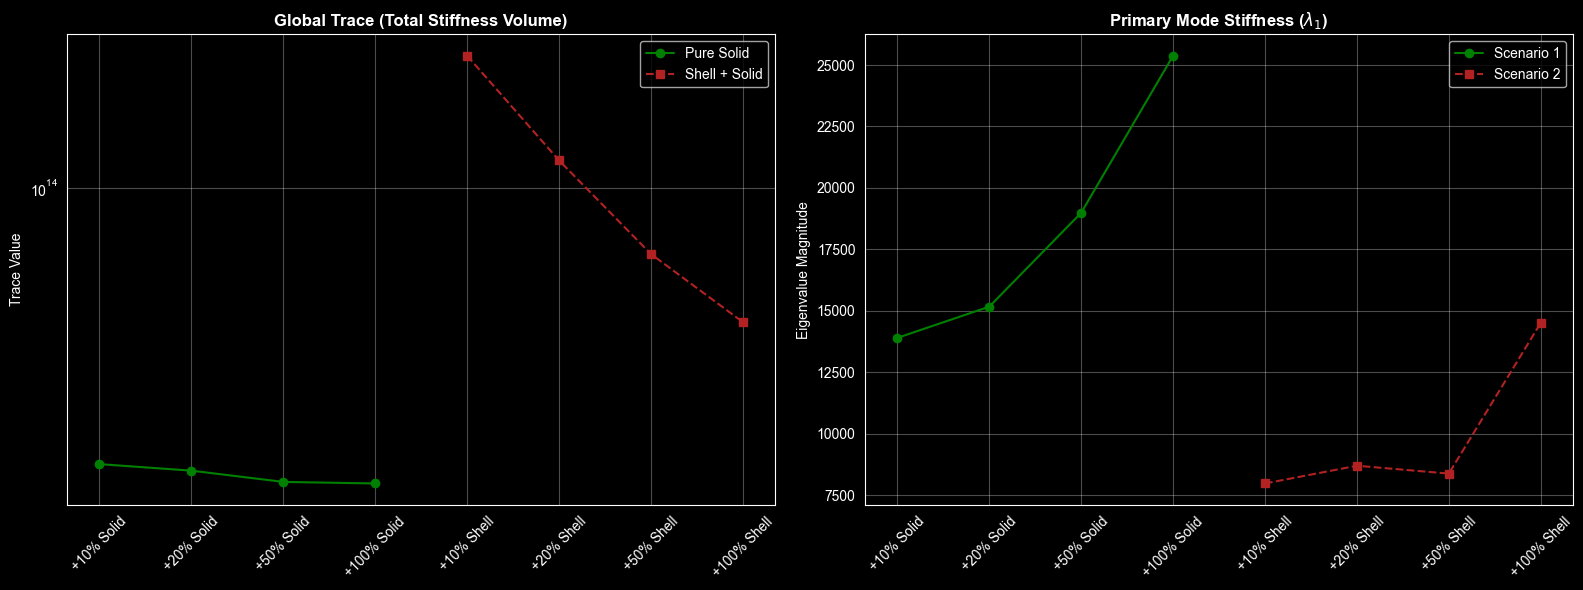

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import eigsh

# --- 1. CONFIGURATION ---
# List your files and their "Real World" thickness labels
cases = {
    "Baseline": "K_baseline_final.mtx",
    "+10% Solid": "K_full_plusten.mtx",
    "+20% Solid": "K_full_plustwenty.mtx",
    "+50% Solid": "K_full_plusfifty.mtx",
    "+100% Solid": "K_full_plushundred.mtx",
    "+10% Shell": "K_full_plustenshell.mtx",
    "+20% Shell": "K_full_plustwentyshell.mtx",
    "+50% Shell": "K_final.mtx",
    "+100% Shell": "K_full_plushundredshell.mtx",
}

data_dir = r"C:\Calculix\ccx_2.23_wsl\Stiffness matrices\Comparison"
results = []

def analyze_matrix(name, file_path):
    try:
        raw_data = np.loadtxt(file_path)
        i, j, v = raw_data[:, 0].astype(int) - 1, raw_data[:, 1].astype(int) - 1, raw_data[:, 2]
        ndof = int(max(i.max(), j.max()) + 1)

        # Reconstruct Full Matrix
        K_ut = coo_matrix((v, (i, j)), shape=(ndof, ndof)).tocsr()
        K = K_ut + K_ut.T - coo_matrix((K_ut.diagonal(), (range(ndof), range(ndof))), shape=(ndof, ndof)).tocsr()

        diags = K.diagonal()
        trace = diags.sum()

        # Calculate First 2 Fundamental Modes
        vals, _ = eigsh(K, k=2, sigma=0, which="LM")
        vals = np.sort(np.abs(vals))

        return {
            "Case": name,
            "DOFs": ndof,
            "Trace": trace,
            "Mode_1": vals[0],
            "Mode_2": vals[1],
            "M2_M1_Ratio": vals[1]/vals[0],
            "Avg_Diag": diags.mean()
        }
    except Exception as e:
        print(f"Skipping {name}: {e}")
        return None

# --- 2. EXECUTION ---
os.chdir(data_dir)
for name, filename in cases.items():
    if os.path.exists(filename):
        res = analyze_matrix(name, filename)
        if res: results.append(res)

df = pd.DataFrame(results)

# --- 3. TABULAR OUTPUT ---
print("\n" + "="*80)
print("STIFFNESS MATRIX COMPARISON SUMMARY")
print("="*80)
print(df.to_string(index=False))
print("="*80)

# --- 4. VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Trace Trend (Global Energy)
solid_df = df[df['Case'].str.contains('Solid|Baseline')]
shell_df = df[df['Case'].str.contains('Shell')]

ax1.plot(solid_df['Case'], solid_df['Trace'], 'o-', label='Pure Solid', color='green')
ax1.plot(shell_df['Case'], shell_df['Trace'], 's--', label='Shell + Solid', color='firebrick')
ax1.set_title("Global Trace (Total Stiffness Volume)", fontweight='bold')
ax1.set_ylabel("Trace Value")
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)
ax1.legend()
plt.setp(ax1.get_xticklabels(), rotation=45)

# Plot B: Fundamental Stiffness (Mode 1)
ax2.plot(solid_df['Case'], solid_df['Mode_1'], 'o-', label='Scenario 1', color='green')
ax2.plot(shell_df['Case'], shell_df['Mode_1'], 's--', label='Scenario 2', color='firebrick')
ax2.set_title("Primary Mode Stiffness ($\lambda_1$)", fontweight='bold')
ax2.set_ylabel("Eigenvalue Magnitude")
ax2.grid(True, alpha=0.3)
ax2.legend()
plt.setp(ax2.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()